In [23]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48

by_Psq = {} 

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items(): #loop through every top-lever group
        if gname == "mN":
            continue  #skip mass group
        q1 = g["Psq_N1"][()][0] #read each momentum label Psq_N1 =  nx^2 + ny^2 + nz^2
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()]) #put the entire E_N1 array into the dictionary list associated with N1's momentum label Psq_N1
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

#numpy array of JUST the keys of the by_Psq dictionary
Psq = np.array(sorted(by_Psq)) 
#numpy array of the physical momentum squared corresponding to each Psq value
p2 = (2*np.pi/L)**2 * Psq 
#2D numpy array where each row corresponds to one Psq value (key of dictionary)
#Column 0: average of all element 0 central energies 
# Columnn 1: average of all element 1 bootstrap (repeat until 5000th boostrap)
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq]) 

In [24]:
print(Psq)
print(p2)
print(E.shape)
print(by_Psq)

[0 1 2 3 4]
[0.         0.01713473 0.03426946 0.05140419 0.06853892]
(5, 5001)
{np.int64(0): [array([0.70279771, 0.70310669, 0.70349985, ..., 0.70291506, 0.70288153,
       0.70292345], shape=(5001,)), array([0.70267872, 0.7035683 , 0.70338813, ..., 0.70246822, 0.70261501,
       0.70294569], shape=(5001,)), array([0.70264518, 0.70305726, 0.70321842, ..., 0.70276664, 0.70271774,
       0.70278394], shape=(5001,)), array([0.7026827 , 0.7033612 , 0.70355962, ..., 0.70275734, 0.70272956,
       0.70284436], shape=(5001,)), array([0.7026827 , 0.7033612 , 0.70355962, ..., 0.70275734, 0.70272956,
       0.70284436], shape=(5001,))], np.int64(1): [array([0.71443606, 0.7148207 , 0.71510476, ..., 0.71467638, 0.71476918,
       0.71443423], shape=(5001,)), array([0.71431716, 0.71491089, 0.715031  , ..., 0.71446924, 0.71446077,
       0.71423564], shape=(5001,)), array([0.71427012, 0.71488908, 0.71503973, ..., 0.71441391, 0.7144599 ,
       0.71398005], shape=(5001,)), array([0.71427012, 0.714889

In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "/Users/summer/Downloads/Dineutron/nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1) #assumes x[0] is the central value, and x[1:] are the bootstrap samples


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0]) #central mass

    for name, g in f.items(): #loop through every top-level group
        if name == "mN":
            continue #skip mN

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
        dE = get_dE(g)

        #Because mN contains 5001 values, E1 and E2 also contains 5001 values 
        E1 = np.sqrt(mN**2 + punit2*N1) # E^2 = m^2 + p^2, where p^2 = (2*pi/L)^2 * N1
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2 #total interacting energy in og lattice frame 

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot) #convert to center of mass energy 
        kstar2 = E_cm**2/4 - mN**2 #calculate the square of the relative momentum
        q2 = kstar2/punit2 #makes momentum dimensionless by dividing by (2*pi/L)^2

        #save for one level
        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2,
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))


In [26]:
print(raw_levels[0])
print(raw_levels[1])

{'name': 'A1g_Psq0_level0', 'irrep': 'A1g', 'Psq_tot': 0, 'level_index': 0, 'pair': (0, 0), 'Ecm_boot': array([1.40448019, 1.40578704, 1.40615159, ..., 1.40526527, 1.40456552,
       1.40507638], shape=(5001,)), 'q2_boot': array([-0.03629042, -0.0383827 , -0.0397186 , ..., -0.0102287 ,
       -0.03663671, -0.02511149], shape=(5001,))}
{'name': 'A1g_Psq0_level1', 'irrep': 'A1g', 'Psq_tot': 0, 'level_index': 1, 'pair': (1, 1), 'Ecm_boot': array([1.42738743, 1.4287276 , 1.42917228, ..., 1.42828707, 1.42771199,
       1.42826525], shape=(5001,)), 'q2_boot': array([0.91018296, 0.91035363, 0.91260329, ..., 0.94154403, 0.9198594 ,
       0.93349681], shape=(5001,))}


Text(0, 0.5, 'E_cm')

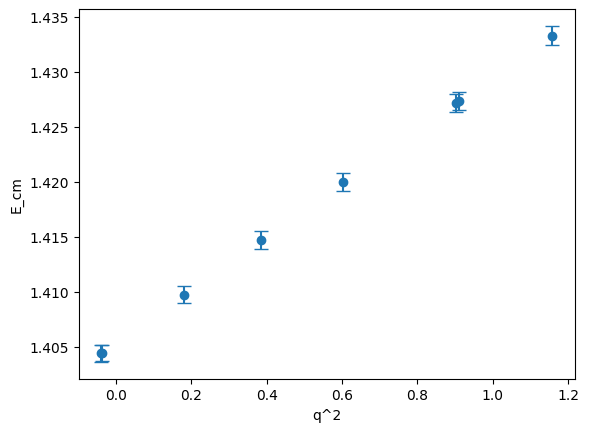

In [27]:
q_squared = []
energy_values = []
energy_errors = []

for level in raw_levels:
    q_squared.append(level["q2_boot"][0])

    central_Ecm = level["Ecm_boot"][0]
    energy_values.append(central_Ecm)

    error_Ecm = boot_err((level["Ecm_boot"]))
    energy_errors.append(error_Ecm)

plt.errorbar(q_squared, energy_values, yerr = energy_errors, fmt='o', capsize=5)
plt.xlabel("q^2")
plt.ylabel("E_cm")

F Function

In [28]:
xi = 0.5


In [30]:
import itertools
from scipy import special as sp

def mySqrt(z):
   return 1j * np.sqrt( -z )

def q_cm_function(s):
  return 0.5 * mySqrt(s - 4.0*m**2)

def rho_function(s):
  return (xi * q_cm_function(s))/(8.0 * np.pi * np.sqrt(s))


def e_cm_function(E, P):
   return np.sqrt(E**2 - np.dot(P,P))

def generate_n_values( shell ):
    final_n_values = []
    allowed_n_values = np.array(np.arange(-shell, shell+1))

    for i in itertools.product(allowed_n_values, allowed_n_values, allowed_n_values):
        tempList = np.array(i)
        if np.dot(tempList, tempList) <= shell**2:
            final_n_values.append(tempList)

    return np.asarray(final_n_values)

def unit_vector( A ):
    if( np.all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime

def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / (2 * np.pi))**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )


def F(E, P, L, final_n_values, alpha): #pass in dimensionless alpha 
   #define variables 
   eps = 1e-16
   e_cm = e_cm_function(E, P)
   s = (e_cm) ** 2

   rho_value = rho_function(s + 1j*eps)
   q_cm_value = q_cm_function(s +1j*eps)
   q_cm_squared = (q_cm_value)**2

   k = (2 * np.pi / L) * final_n_values
   omega = np.sqrt(m**2 + np.sum(k**2, axis=1))
   beta = P / E
   omega_cm, k_cm = lorentzBoost( omega, k, beta)
   k_cm_squared = np.sum(k_cm**2, axis=1)

   #first term 
   first_term = 1j * rho_value

   #second term
   cutoff_values = cutoff(q_cm_squared, k_cm_squared, alpha, L)
   goes_in_sum= (omega_cm / omega) * (cutoff_values / (q_cm_squared - k_cm_squared))
   second_term = (xi / (2 * e_cm * L**3)) * np.sum(goes_in_sum)

   #third term
   alpha_dim = (L / (2 * np.pi))**2 * alpha
   third_term_one = (xi)/ (4.0 * np.pi**2 * e_cm)
   third_term_two = (np.sqrt(np.pi/ (4.0 * alpha_dim)) * np.exp(alpha_dim * q_cm_squared))
   z = np.sqrt(alpha_dim) * q_cm_value
   third_term_three = ((np.pi * q_cm_value)/2) * sp.erfi( z )

   third_term = third_term_one * (third_term_two - third_term_three)

   F_pv = second_term.real + third_term
   F_value = first_term + F_pv
   return F_value, F_pv




Plot M vs q^2

In [43]:
shell = 20
alpha = 0.125
final_n_values = generate_n_values(shell)

q2_values = []
F_values = []
F_pv_values = []

for level in raw_levels:
    E_cm = float(level["Ecm_boot"][0])

    Psq_tot = int(level["Psq_tot"])
    nP = dvec_from_d2(Psq_tot)

    P = (2*np.pi/L) * nP

    E_lab = np.sqrt(E_cm**2 + np.dot(P,P))

    F_value, F_pv_value = F(E_lab, P, L, final_n_values, alpha)

    q2_values.append(float(level["q2_boot"][0]))
    F_values.append(F_value)
    F_pv_values.append(F_pv_value)

for level, q2, F_value, F_pv_value in zip(raw_levels, q2_values, F_values, F_pv_values):
    print(
    f"{level['name']}: "
    f"q^2 = {q2:.4f}, "
    f"F = {F_value.real:.4f} + {F_value.imag:.4f}j, "
    f"F_pv = {F_pv_value.real:.4f}"
)

A1g_Psq0_level0: q^2 = -0.0363, F = -0.0020 + 0.0000j, F_pv = -0.0017
A1g_Psq0_level1: q^2 = 0.9102, F = -0.0059 + 0.0017j, F_pv = -0.0059
A1_Psq1_level0: q^2 = 0.1814, F = -0.0021 + 0.0008j, F_pv = -0.0021
A1_Psq1_level1: q^2 = 1.1579, F = -0.0078 + 0.0020j, F_pv = -0.0078
A1_Psq2_level0: q^2 = 0.3858, F = -0.0027 + 0.0011j, F_pv = -0.0027
A1_Psq3_level0: q^2 = 0.6022, F = -0.0043 + 0.0014j, F_pv = -0.0043
A1_Psq4_level0: q^2 = -0.0387, F = -0.0019 + 0.0000j, F_pv = -0.0015
A1_Psq4_level1: q^2 = 0.9016, F = -0.0062 + 0.0017j, F_pv = -0.0062


In [32]:
M_values = []
M_real_values = []
M_imag_values = []
for F_value in F_values:
    M_values.append(-1.0 / F_value )

for M in M_values:
    M_real_values.append(M.real)
    M_imag_values.append(M.imag )

Text(0.5, 1.0, 'Imaginary part of M vs q^2')

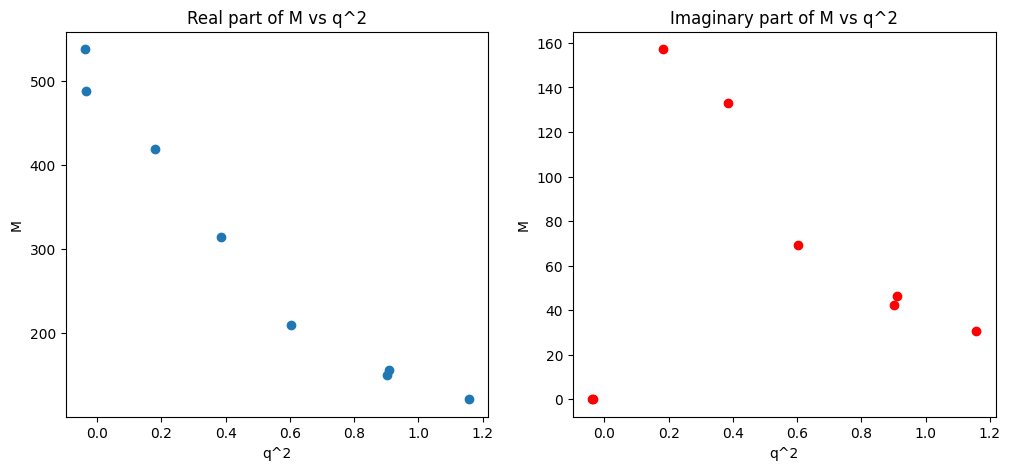

In [36]:

plt.figure(figsize=(12, 5))
ax1 = plt.gcf().add_subplot(121)
ax2 = plt.gcf().add_subplot(122)

ax1.scatter(q2_values, M_real_values, label="Real part of M")
ax1.set_xlabel("q^2")
ax1.set_ylabel("M")
ax1.set_title("Real part of M vs q^2")

ax2.scatter(q2_values, M_imag_values, label="Imaginary part of M", color = 'red')
ax2.set_xlabel("q^2")
ax2.set_ylabel("M")
ax2.set_title("Imaginary part of M vs q^2")

Plot qcotdelta vs q^2

In [51]:
q_cot_delta_values = []

for i in range(len(raw_levels)):

    #get level
    level = raw_levels[i]

    #get F_pv 
    F_pv_value = F_pv_values[i]

    #CM 
    E_cm = float(level["Ecm_boot"][0])

    #q* cot(delta = -(8* pi * E_cm / xi)(F_pv)
    q_cot_delta = -(8.0 * np.pi * E_cm / xi) * F_pv_value

    q_cot_delta_values.append(q_cot_delta.real)

Text(0.5, 1.0, 'q^* cot delta vs q^2')

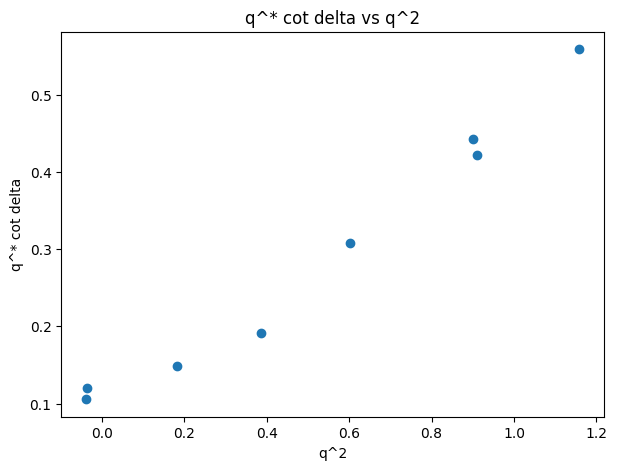

In [52]:
plt.figure(figsize=(7,5))

plt.scatter(q2_values, q_cot_delta_values)
plt.xlabel("q^2")
plt.ylabel("q^* cot delta")
plt.title("q^* cot delta vs q^2")



In [53]:
for i in range(len(raw_levels)):
    print(
        f"{raw_levels[i]['name']:20s}",
        f"q² = {q2_values[i]:7.4f}",
        f"Fpv = {F_pv_values[i]:10.6f}",
        f"q*cotδ = {q_cot_delta_values[i]:10.6f}"
    )

A1g_Psq0_level0      q² = -0.0363 Fpv = -0.001696-0.000000j q*cotδ =   0.119715
A1g_Psq0_level1      q² =  0.9102 Fpv = -0.005878-0.000000j q*cotδ =   0.421758
A1_Psq1_level0       q² =  0.1814 Fpv = -0.002094-0.000000j q*cotδ =   0.148413
A1_Psq1_level1       q² =  1.1579 Fpv = -0.007759-0.000000j q*cotδ =   0.558986
A1_Psq2_level0       q² =  0.3858 Fpv = -0.002699-0.000000j q*cotδ =   0.191950
A1_Psq3_level0       q² =  0.6022 Fpv = -0.004309-0.000000j q*cotδ =   0.307546
A1_Psq4_level0       q² = -0.0387 Fpv = -0.001496-0.000000j q*cotδ =   0.105636
A1_Psq4_level1       q² =  0.9016 Fpv = -0.006165-0.000000j q*cotδ =   0.442291
